In [2]:
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, parent_dir)

In [3]:
from probts.model.forecaster import GRUForecaster
from probts.model.forecast_module import ProbTSForecastModule
from probts.data import ProbTSDataModule, DataManager, ProbTSBatchData
from probts.utils import find_best_epoch
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
import torch
import matplotlib.pyplot as plt

In [4]:
data_manager = DataManager(
    dataset='etth1',
    path='../datasets',
    context_length=96,
    prediction_length=96,
    scaler='standard',
)
datamodule = ProbTSDataModule(
    data_manager=data_manager,
    batch_size=32,
    test_batch_size=32,
    num_workers=0,
)
test_dataloader = datamodule.test_dataloader()
train_dataloader = datamodule.train_dataloader()
val_dataloader = datamodule.val_dataloader()

Loading Long-term Dataset: etth1
val  pred_len: 96 : num_test_windows: 29
test  pred_len: 96 : num_test_windows: 29
Test context length: [96], prediction length: [96]
Validation context length: [96], prediction length: [96]
Training context length: [96], prediction lengths: [96]
Test rolling length: 96
Variable-specific normalization: True


/Users/vitaliypozdnyakov/Yandex.Disk.localized/Data Science/ProbTS/probts/data/data_utils/get_datasets.py:138: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_stamp['date'] = pd.to_datetime(df_stamp.date, format=data_format)


In [5]:
for test_batch in test_dataloader:
    break

In [30]:
forecaster = GRUForecaster(
    num_layers=4,
    dropout=0,
    f_hidden_size=32,
    individual=True,
    use_lags=False,
    use_feat_idx_emb=False,
    use_time_feat=False,
    target_dim=data_manager.target_dim, 
    context_length=data_manager.context_length,
    prediction_length=data_manager.prediction_length,
    freq=data_manager.freq,
    lags_list=data_manager.lags_list,
    time_feat_dim=data_manager.time_feat_dim,
    dataset=data_manager.dataset,
)

model = ProbTSForecastModule(
    forecaster=forecaster, 
    scaler=data_manager.scaler, 
    learning_rate=0.00001,
)

sampling_weight_scheme: none


In [31]:
checkpoint_callback = ModelCheckpoint(
    save_top_k=1,       
    save_weights_only=False,
    every_n_epochs=1,
    monitor="val_CRPS", 
    mode="min",
)
trainer = Trainer(
    accelerator="cpu",
    devices=1,
    strategy="auto",
    max_epochs=30,
    use_distributed_sampler=False,
    limit_train_batches=100,
    log_every_n_steps=1,
    accumulate_grad_batches=1,
    logger=CSVLogger('./logs'),
    callbacks=[checkpoint_callback],
)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [32]:
trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)


  | Name       | Type          | Params | Mode 
-----------------------------------------------------
0 | forecaster | GRUForecaster | 23.2 K | train
-----------------------------------------------------
23.2 K    Trainable params
0         Non-trainable params
23.2 K    Total params
0.093     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                               | 0/? [00:00<…

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_epochs=30` reached.


In [33]:
model = ProbTSForecastModule.load_from_checkpoint(
    checkpoint_path=checkpoint_callback.best_model_path,
    scaler=datamodule.data_manager.scaler,
    context_length=datamodule.data_manager.context_length,
    target_dim=datamodule.data_manager.target_dim,
    freq=datamodule.data_manager.freq,
    prediction_length=datamodule.data_manager.prediction_length,
    train_pred_len_list=datamodule.data_manager.train_pred_len_list,
    lags_list=datamodule.data_manager.lags_list,
    time_feat_dim=datamodule.data_manager.time_feat_dim,
    no_training=forecaster.no_training,
    sampling_weight_scheme=model.sampling_weight_scheme,
)

sampling_weight_scheme: none


In [34]:
batch_data = ProbTSBatchData(test_batch, model.device)
past_target_cdf = model.scaler.transform(batch_data.past_target_cdf)
future_target_cdf = model.scaler.transform(batch_data.future_target_cdf)
batch_data.past_target_cdf = past_target_cdf

batch_idx = 1
with torch.no_grad():
    prediction = model.forecaster.forecast(batch_data)
prediction = prediction[batch_idx, 0, :, :]
prediction.shape

torch.Size([96, 7])

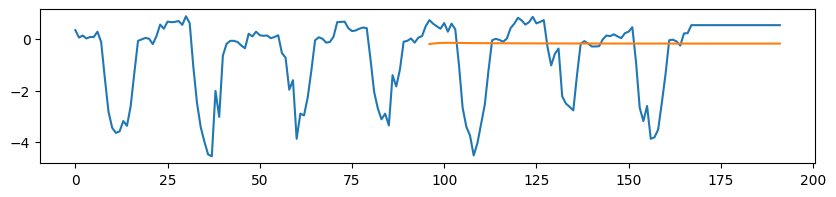

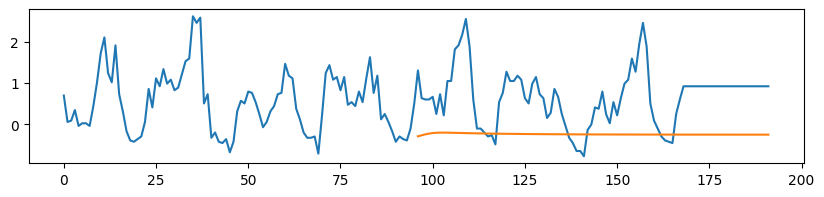

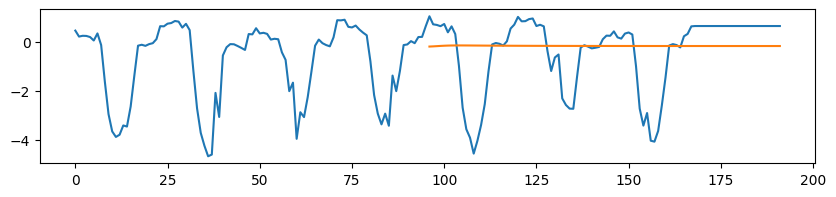

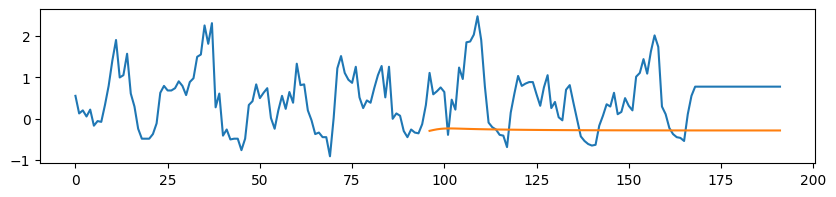

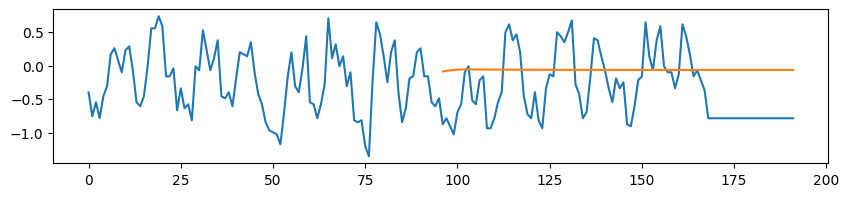

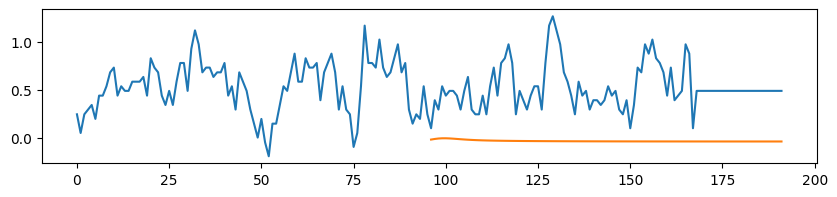

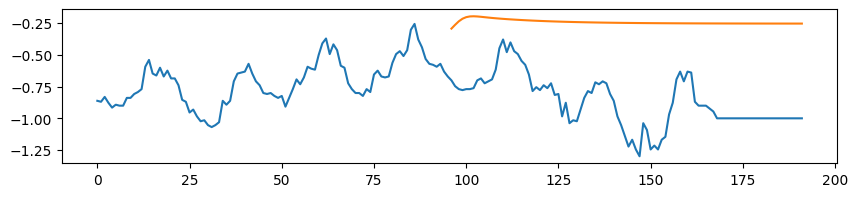

In [35]:
context_length = data_manager.context_length
prediction_length = data_manager.prediction_length
past_range = range(0, context_length)
future_range = range(context_length, context_length + prediction_length)
full_range = range(0, context_length + prediction_length)

for i in range(min(10, forecaster.target_dim)):
    target = torch.cat([past_target_cdf[batch_idx, -context_length:, i], future_target_cdf[batch_idx, :, i]])
    plt.figure(figsize=(10, 2))
    plt.plot(full_range, target)
    plt.plot(future_range, prediction[:, i])

In [36]:
trainer.test(model=model, datamodule=datamodule);

Testing: |                                                                                       | 0/? [00:00<…

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
      96_test_CRPS          0.7964620590209961
    96_test_CRPS-Sum        0.37512561678886414
      96_test_MASE           2.639866590499878
       96_test_MSE           33.95759963989258
     96_test_MSE-Sum        248.83482360839844
       96_test_ND           0.7964620590209961
     96_test_ND-Sum         0.37512561678886414
      96_test_NRMSE         1.2435613870620728
    96_test_NRMSE-Sum       0.5431719422340393
   96_test_weighted_ND      0.7964620590209961
 96_test_weighted_ND-Sum    0.37512561678886414
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
